## STEP 1: The Robust Face Extractor

In [1]:
import cv2
import os
import numpy as np

IMG_SIZE = 128
FRAMES_PER_VIDEO = 10 # 10 is the perfect balance for memory vs. accuracy

FACE_CASCADE = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
print("Cascade loaded:", not FACE_CASCADE.empty())

def crop_face(frame, padding=0.2):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    faces = FACE_CASCADE.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5, minSize=(40, 40))
    
    h, w = frame.shape[:2]
    if len(faces) == 0:
        # Fallback: Center crop
        margin_h, margin_w = int(h*0.2), int(w*0.2)
        crop = frame[margin_h:h-margin_h, margin_w:w-margin_w]
        return cv2.resize(crop, (IMG_SIZE, IMG_SIZE))

    x, y, fw, fh = max(faces, key=lambda f: f[2] * f[3])
    pad_x, pad_y = int(fw * padding), int(fh * padding)
    x1, y1 = max(0, x - pad_x), max(0, y - pad_y)
    x2, y2 = min(w, x + fw + pad_x), min(h, y + fh + pad_y)

    face_crop = frame[y1:y2, x1:x2]
    return cv2.resize(face_crop, (IMG_SIZE, IMG_SIZE))

def extract_frames(video_path, n_frames=FRAMES_PER_VIDEO):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return []

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0: return []

    indices = np.linspace(int(total*0.1), int(total*0.9), n_frames, dtype=int)
    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret: continue
        
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(crop_face(frame))

    cap.release()
    return frames
    
print("Step 1 Complete: Extractor Ready.")

Cascade loaded: True
Step 1 Complete: Extractor Ready.


## STEP 2: Strict Balanced Loading & Memory Optimization

In [2]:
import random

random.seed(42)
np.random.seed(42)

MAX_REAL = 1000   
MAX_FAKE = 1000   
VAL_RATIO = 0.2  

real_path = "FaceForensics++/real_original_sequences"
fake_path = "FaceForensics++/fake_manipulated_sequences"

real_videos = sorted([os.path.join(real_path, v) for v in os.listdir(real_path) if v.endswith('.mp4')])[:MAX_REAL]

fake_folders = sorted(os.listdir(fake_path))
per_folder = MAX_FAKE // len(fake_folders)

fake_videos = []
for folder in fake_folders:
    fp = os.path.join(fake_path, folder)
    if os.path.isdir(fp):
        vids = sorted([os.path.join(fp, v) for v in os.listdir(fp) if v.endswith('.mp4')])[:per_folder]
        fake_videos.extend(vids)

print(f"Real videos to use: {len(real_videos)}")
print(f"Fake videos to use: {len(fake_videos)}")

random.shuffle(real_videos)
random.shuffle(fake_videos)

n_real_val = int(len(real_videos) * VAL_RATIO)
n_fake_val = int(len(fake_videos) * VAL_RATIO)

real_val_vids, real_train_vids = real_videos[:n_real_val], real_videos[n_real_val:]
fake_val_vids, fake_train_vids = fake_videos[:n_fake_val], fake_videos[n_fake_val:]

def load_split(real_vids, fake_vids, split_name):
    X, y = [], []
    total = len(real_vids) + len(fake_vids)
    done = 0

    for vpath in real_vids:
        for f in extract_frames(vpath):
            X.append(f)
            y.append(1) # REAL = 1
        done += 1
        if done % 100 == 0: print(f"  {split_name}: {done}/{total} videos processed")

    for vpath in fake_vids:
        for f in extract_frames(vpath):
            X.append(f)
            y.append(0) # FAKE = 0
        done += 1
        if done % 100 == 0: print(f"  {split_name}: {done}/{total} videos processed")

    # Keep as float32, but do NOT divide by 255. ImageDataGenerator will handle preprocessing.
    X = np.array(X, dtype="float32") 
    y = np.array(y, dtype="int32")
    
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

print("\nExtracting TRAIN frames...")
X_train, y_train = load_split(real_train_vids, fake_train_vids, "Train")

print("\nExtracting VAL frames...")
X_val, y_val = load_split(real_val_vids, fake_val_vids, "Val")

Real videos to use: 1000
Fake videos to use: 1000

Extracting TRAIN frames...
  Train: 100/1600 videos processed
  Train: 200/1600 videos processed
  Train: 300/1600 videos processed
  Train: 400/1600 videos processed
  Train: 500/1600 videos processed
  Train: 600/1600 videos processed
  Train: 700/1600 videos processed
  Train: 800/1600 videos processed
  Train: 900/1600 videos processed
  Train: 1000/1600 videos processed
  Train: 1100/1600 videos processed
  Train: 1200/1600 videos processed
  Train: 1300/1600 videos processed
  Train: 1400/1600 videos processed
  Train: 1500/1600 videos processed
  Train: 1600/1600 videos processed

Extracting VAL frames...
  Val: 100/400 videos processed
  Val: 200/400 videos processed
  Val: 300/400 videos processed
  Val: 400/400 videos processed


## STEP 3: Fine-Tuning MobileNetV2 with Data Augmentation

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Data Augmentation (Crucial for generalizing Deepfakes)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    rotation_range=10
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow(X_train, y_train, batch_size=64, shuffle=True)
val_gen = val_datagen.flow(X_val, y_val, batch_size=64, shuffle=False)

# 2. Base Model Setup
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

# FINE-TUNING: Unfreeze the top 50 layers
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Custom Head Setup
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Use a lower learning rate (1e-4) because we are fine-tuning pre-trained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

print("Starting Fine-Tuning Process...")
history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks
)

Starting Fine-Tuning Process...


C:\Users\admin\.conda\envs\datasci\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - accuracy: 0.6963 - auc: 0.7688 - loss: 0.6362 - val_accuracy: 0.5040 - val_auc: 0.5999 - val_loss: 1.8042 - learning_rate: 1.0000e-04
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 454s 2s/step - accuracy: 0.8293 - auc: 0.9085 - loss: 0.3951 - val_accuracy: 0.5383 - val_auc: 0.7100 - val_loss: 1.8161 - learning_rate: 1.0000e-04
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.8668 - auc: 0.9382 - loss: 0.3256 - val_accuracy: 0.5993 - val_auc: 0.7208 - val_loss: 1.4496 - learning_rate: 1.0000e-04
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 454s 2s/step - accuracy: 0.8922 - auc: 0.9605 - loss: 0.2561 - val_accuracy: 0.6240 - val_auc: 0.7295 - val_loss: 1.7429 - learning_rate: 1.0000e-04
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9121 - auc: 0.9710 - loss: 0.2182  
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
250/250 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - accuracy: 0.9112 - auc:

## STEP 4: Comprehensive Evaluation & Optimal Threshold Calculation

Calculating Validation Predictions...
--- MODEL METRICS ---
Optimal Classification Threshold: 0.0825


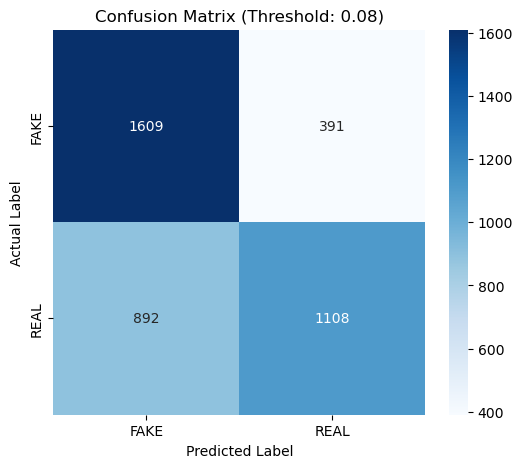


Classification Report:
              precision    recall  f1-score   support

        FAKE       0.64      0.80      0.71      2000
        REAL       0.74      0.55      0.63      2000

    accuracy                           0.68      4000
   macro avg       0.69      0.68      0.67      4000
weighted avg       0.69      0.68      0.67      4000


Model and Threshold Configuration Saved Successfully!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

# Get actual probabilities from the validation set
print("Calculating Validation Predictions...")
y_pred_probs = model.predict(val_gen, verbose=0).flatten()

# 1. Calculate Optimal Threshold using Youden's J statistic
fpr, tpr, thresholds = roc_curve(y_val, y_pred_probs)
optimal_idx = np.argmax(tpr - fpr)
OPTIMAL_THRESHOLD = thresholds[optimal_idx]

print("--- MODEL METRICS ---")
print(f"Optimal Classification Threshold: {OPTIMAL_THRESHOLD:.4f}")

# Convert probabilities to binary predictions based on OPTIMAL threshold
y_pred_binary = (y_pred_probs >= OPTIMAL_THRESHOLD).astype(int)

# 2. Confusion Matrix
cm = confusion_matrix(y_val, y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.title(f'Confusion Matrix (Threshold: {OPTIMAL_THRESHOLD:.2f})')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 3. Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_binary, target_names=['FAKE', 'REAL']))

# Save Model and the Threshold Config
model.save("Deepfake_MobileNetV2_FineTuned.keras")
import json
with open("detector_config.json", "w") as f:
    json.dump({"optimal_threshold": float(OPTIMAL_THRESHOLD)}, f)
print("\nModel and Threshold Configuration Saved Successfully!")

## STEP 5: Final Video Prediction Function

In [5]:
import json
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load threshold dynamically
try:
    with open("detector_config.json", "r") as f:
        cfg = json.load(f)
        THRESHOLD = cfg["optimal_threshold"]
except:
    THRESHOLD = 0.5 # Fallback

def predict_video(video_path):
    frames = extract_frames(video_path)
    if len(frames) == 0:
        return "Error: Could not extract frames."

    # Convert to float32 and apply MobileNet preprocessing
    frames_array = np.array(frames, dtype="float32")
    frames_array = preprocess_input(frames_array)
    
    preds = model.predict(frames_array, verbose=0).flatten()
    avg_pred = float(np.mean(preds))

    # Use the calculated optimal threshold!
    is_real = avg_pred >= THRESHOLD 
    label = "REAL" if is_real else "FAKE"
    
    # Calculate Confidence relative to the optimal threshold
    if is_real:
        confidence = ((avg_pred - THRESHOLD) / (1.0 - THRESHOLD)) * 100
    else:
        confidence = ((THRESHOLD - avg_pred) / THRESHOLD) * 100
        
    print(f"Prediction: {label:5} | Confidence: {confidence:5.1f}% | Raw Score: {avg_pred:.4f} | Threshold: {THRESHOLD:.4f}")
    return label, confidence

print("\n--- Live Video Tests ---")
# Example usage:
predict_video("FaceForensics++/real_original_sequences/011.mp4")
predict_video("FaceForensics++/fake_manipulated_sequences/Deepfakes/007_132.mp4")


--- Live Video Tests ---
Prediction: REAL  | Confidence:  23.6% | Raw Score: 0.2988 | Threshold: 0.0825
Prediction: FAKE  | Confidence:  98.2% | Raw Score: 0.0015 | Threshold: 0.0825


('FAKE', 98.16757259458508)